# Mbrain results

T168 real, 20 simulation steps, and T170 real.

## Settings

In [ ]:
from pathlib import Path
import yaml

DATASET = 'Mbrain'
CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / DATASET
REPO_ROOT = EXPERIMENT_DIR.parents[1]
import sys

CONFIG = yaml.safe_load(
    (EXPERIMENT_DIR / "config.yaml").read_text(encoding="utf-8")
)

def experiment_path(value):
    path = Path(value)
    return path if path.is_absolute() else (EXPERIMENT_DIR / path).resolve()

RUN_ROOT = experiment_path(CONFIG["run_root"])
SCANVI_DIR = experiment_path(CONFIG["scanvi_dir"])
SCANVI_ADATA = SCANVI_DIR / "adata.h5ad"
STAGE1_CHECKPOINT_ROOT = experiment_path(CONFIG["stage1_checkpoint"])

import json
sys.path.insert(0, str(REPO_ROOT))
from tutorial_utils.frame_gallery import load_gallery, plot_gallery

PALETTE = json.loads((EXPERIMENT_DIR / "colors.json").read_text())
ROUTE_IDS = list(CONFIG["route_ids"])
ROUTES = list(zip(ROUTE_IDS[:-1], ROUTE_IDS[1:]))
INPUT_PATH = SCANVI_ADATA
INTERVAL = 1


## Simulation frames

In [ ]:
segments = []
for src, tgt in ROUTES:
    route = f"{src}_to_{tgt}"
    frame_dir = RUN_ROOT / "simulation" / route
    segments.append({"src": src, "tgt": tgt, "frame_dir": frame_dir,
                     "checkpoint": STAGE1_CHECKPOINT_ROOT / route / "checkpoints" / "best.pt"})

panels = load_gallery(INPUT_PATH, 'sample', CONFIG["celltype_source_key"],
                      segments, dimension=CONFIG["spatial_dimension"], interval=INTERVAL)


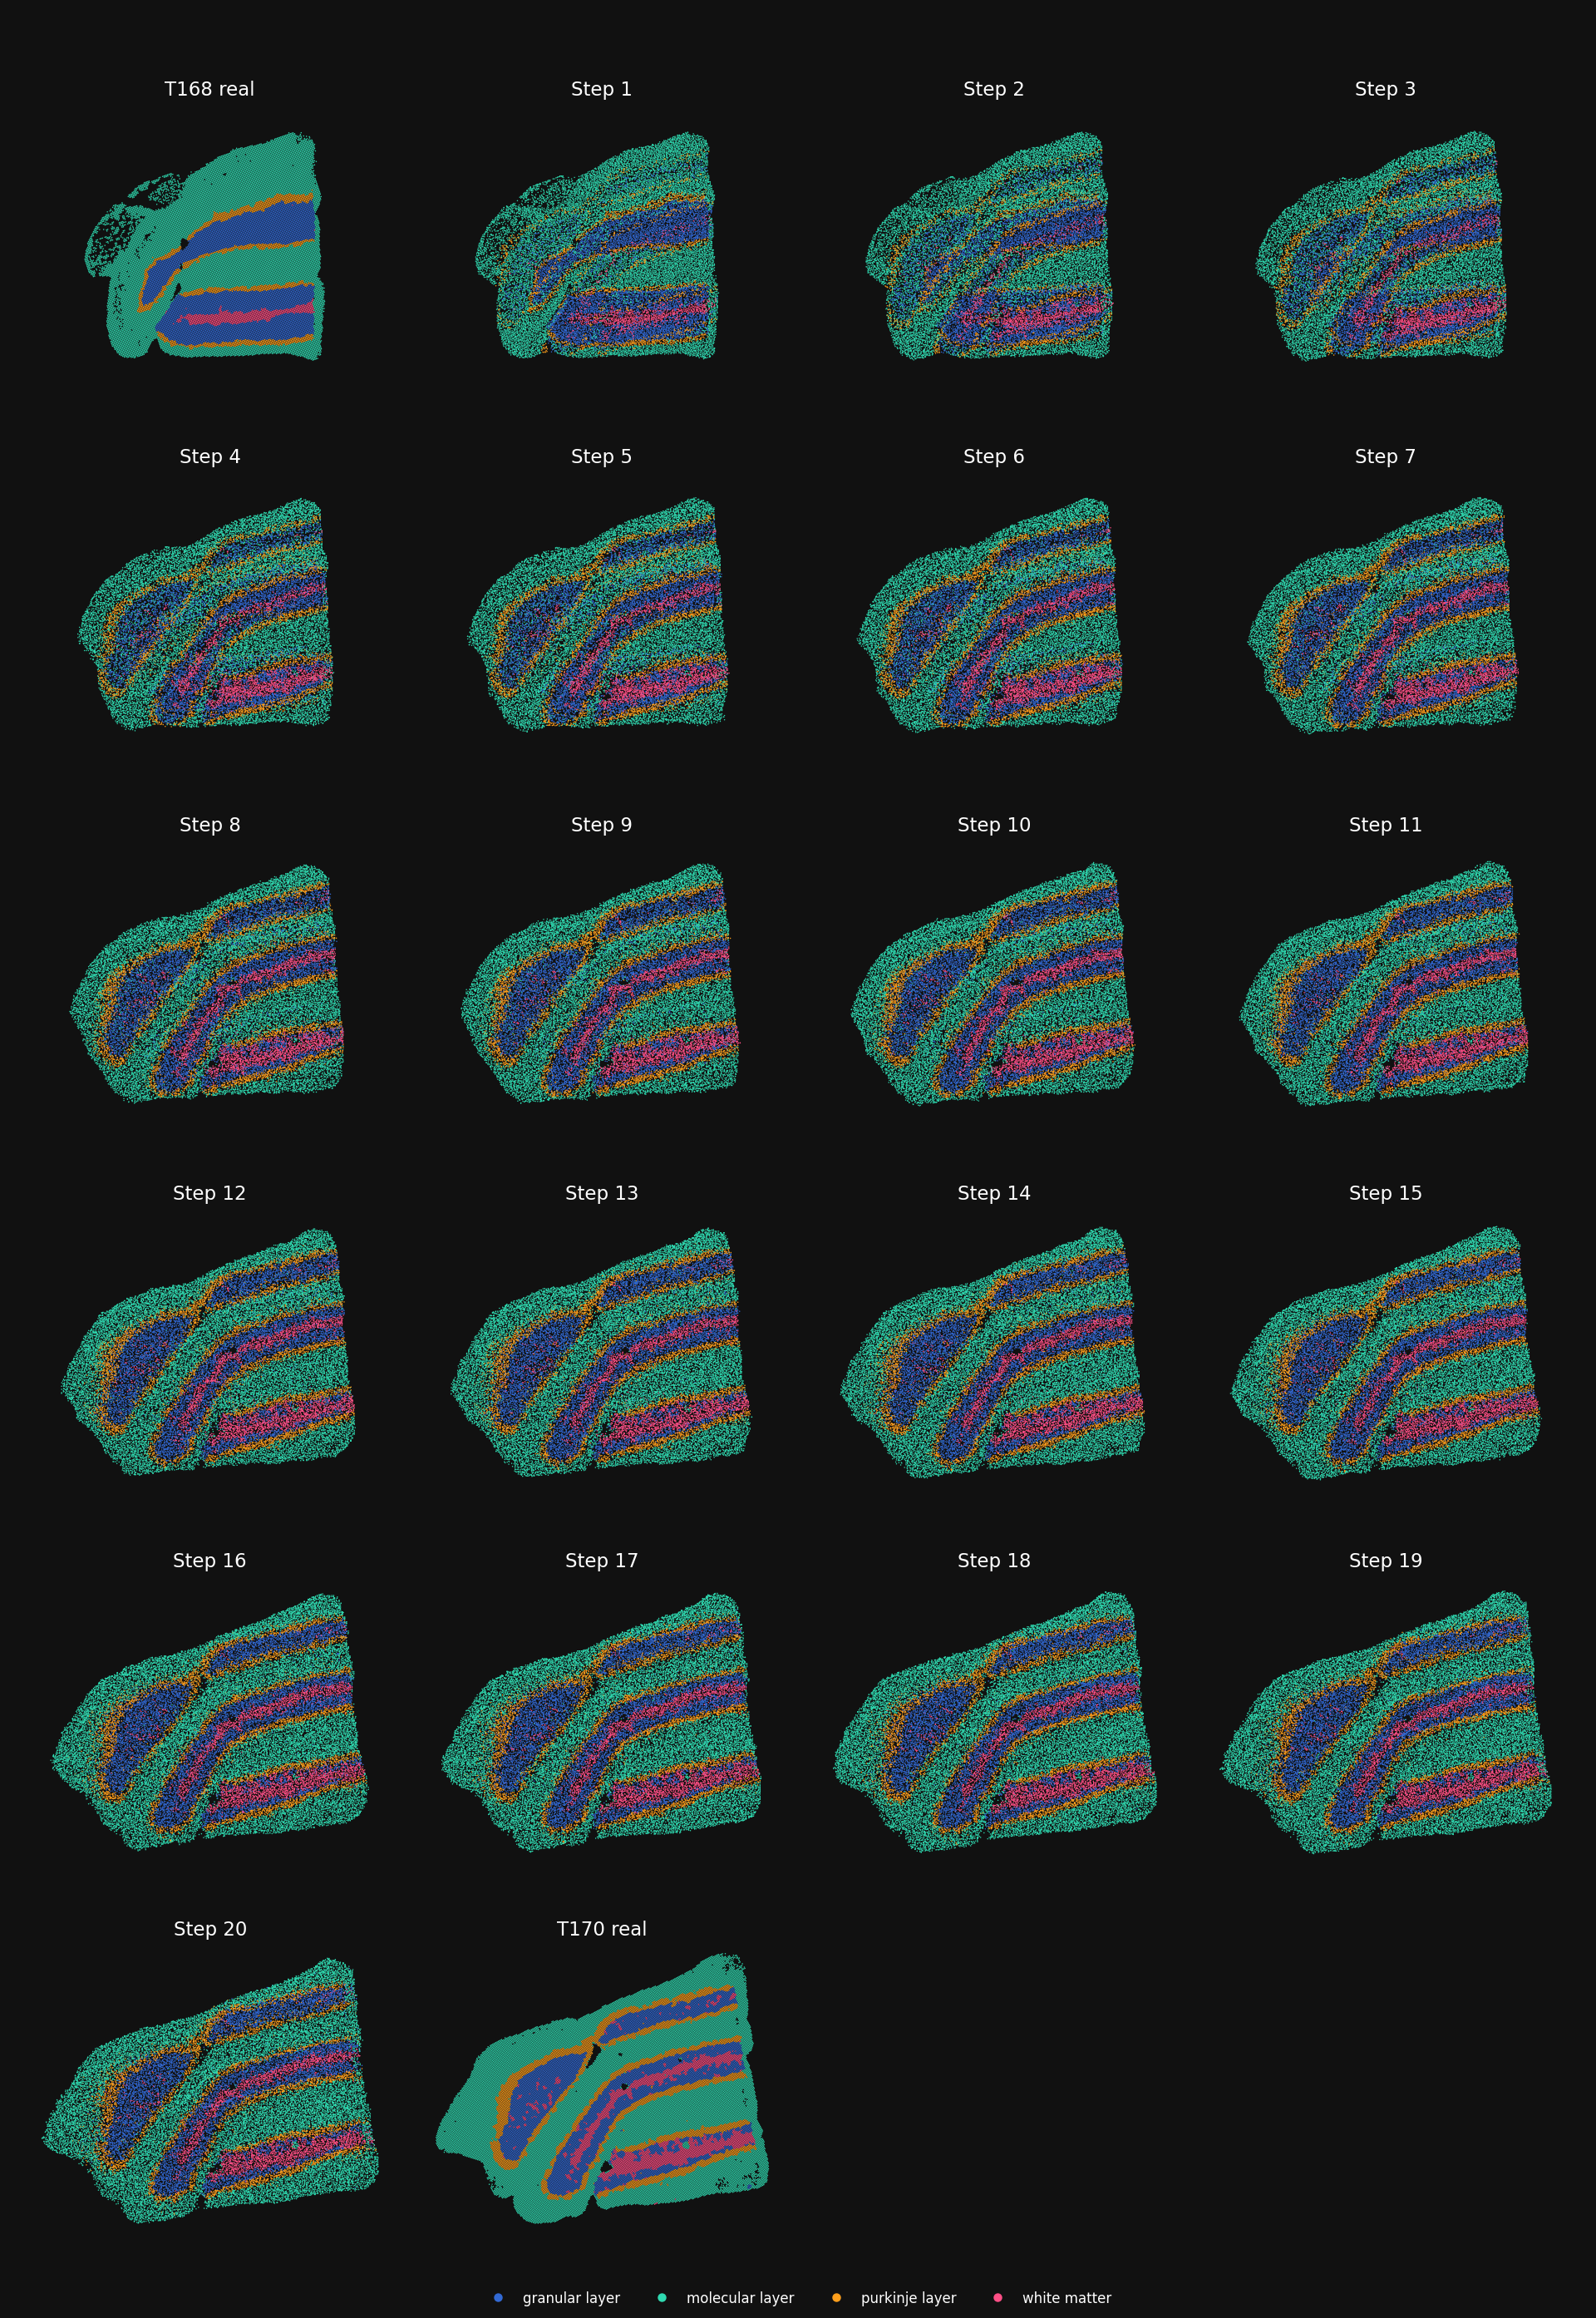

In [ ]:
fig = plot_gallery(panels, PALETTE, dimension=CONFIG["spatial_dimension"],
                   flip_y=False)
import matplotlib.pyplot as plt
plt.show()

## Mean gene expression

Compare Real and stVirtual at the middle section, **T169** (T168 to T170).

Normalize each cell to 10,000 counts (CP10k), average each gene across cells including zeros, then apply log1p: **log1p(mean(CP10k))**.

Read the saved R3/C3 evaluation results below. The expression values are already calculated. Negative violin tails are KDE smoothing; the saved values are nonnegative.


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

EXPRESSION_TABLE = EXPERIMENT_DIR / "expression_results" / "T168_to_T170_T169_log_of_mean.csv.gz"
EXPRESSION_INFO = EXPRESSION_TABLE.parent / "provenance.json"
expression_info = json.loads(EXPRESSION_INFO.read_text())
log_mean = pd.read_csv(
    EXPRESSION_TABLE, float_precision="round_trip",
    keep_default_na=False, dtype={"gene": str},
)[["gene", "Real", "stVirtual"]]
assert len(log_mean) == expression_info["n_genes"]
assert log_mean["gene"].is_unique
assert np.isfinite(log_mean[["Real", "stVirtual"]].to_numpy()).all()
assert (log_mean[["Real", "stVirtual"]].to_numpy() >= 0).all()


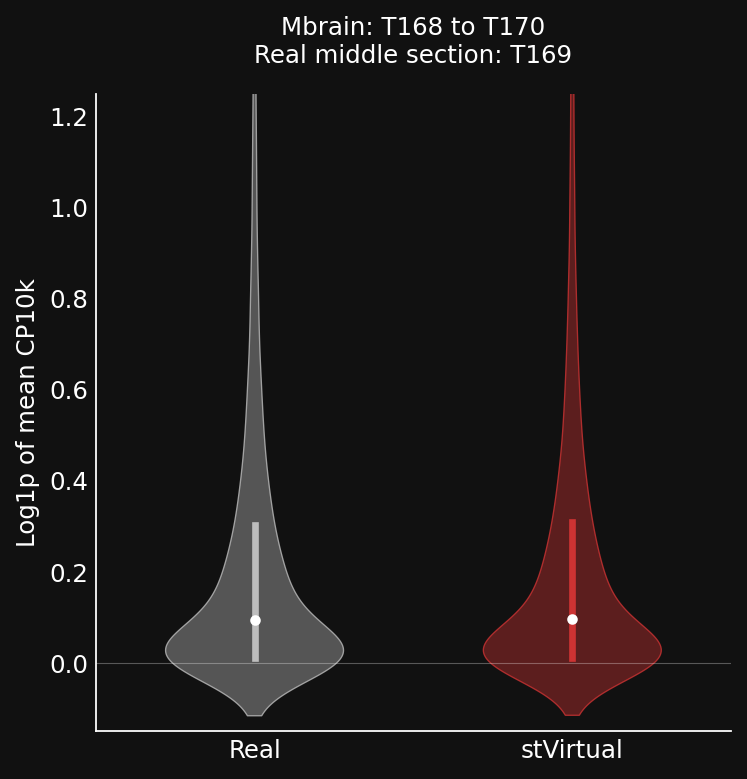

In [3]:

with plt.rc_context({"font.family": "DejaVu Sans", "font.size": 11}):
    expression_fig, ax = plt.subplots(figsize=(4.8, 5), dpi=160)
    expression_fig.patch.set_facecolor("#111111")
    ax.set_facecolor("#111111")
    ymin, ymax = expression_info["axis_limits"]
    methods = ["Real", "stVirtual"]
    from matplotlib.colors import to_rgba

    for position, method in enumerate(methods):
        values = log_mean[method].to_numpy()
        density = gaussian_kde(values, bw_method="scott")
        bandwidth = float(np.sqrt(density.covariance[0, 0]))
        lower = float(values.min() - 2 * bandwidth)
        upper = float(values.max() + 2 * bandwidth)
        grid = np.unique(np.r_[
            np.linspace(lower, upper, 250),
            np.linspace(lower, ymax, 400),
        ])
        width = density(grid)
        width *= 0.28 / width.max()
        color = expression_info["colors"][method]
        ax.fill_betweenx(
            grid, position - width, position + width,
            facecolor=to_rgba(color, 0.4),
            edgecolor=to_rgba(color, 0.8), linewidth=0.6,
        )
        q25, median, q75 = np.quantile(values, [0.25, 0.5, 0.75])
        ax.plot([position, position], [q25, q75], color=color, linewidth=3)
        ax.scatter(position, median, color="white", s=14, zorder=4)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([0, 1], methods)
    ax.set_ylabel("Log1p of mean CP10k", color="white")
    ax.set_title(
        f'{expression_info["dataset"]}: {expression_info["display_window"]}'
        f'\nReal middle section: {expression_info["display_middle"]}',
        color="white", fontsize=11, pad=14,
    )
    ax.tick_params(colors="white", length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("white")
    ax.spines["bottom"].set_color("white")
    ax.axhline(0, color="white", linewidth=0.5, alpha=0.3)
    ax.grid(False)
    expression_fig.tight_layout()
    plt.show()
